# Week 2: Spectrum, Sampling, and Signal Analysis

ECE 5377/7377 Embedded Wireless Design Laboratory

Python/Jupyter version of the Week 2 numerical demonstration. Run this notebook after the prediction slide.

## Instructor orientation

This is still the same Week 2 executable notebook. I have added extensive teaching commentary without changing the calculations.

For Jupyter:

- **Shift+Enter** executes the current cell and moves to the next cell.
- All cells share the same running Python **kernel**.
- Variables created in one cell remain alive for later cells.
- `[1]`, `[2]`, etc. are execution counts, not outputs.
- If execution order becomes confusing, use **Kernel → Restart Kernel** and run from the top.

Useful inspection commands in a temporary code cell:

```python
%whos
```

```python
x[:10]
```

```python
type(x)
```

## C/C++ mental model

NumPy usually replaces explicit numerical loops. For example,

```python
x = np.cos(2*np.pi*f*t)
```

is conceptually similar to

```cpp
for (int i = 0; i < N; ++i)
    x[i] = cos(2.0 * M_PI * f * t[i]);
```

The notebook develops a single chain of ideas:

1. build a signal in time,
2. inspect it in frequency with the FFT,
3. see how record duration controls FFT-bin spacing,
4. connect a rectangle in time to a sinc spectrum,
5. use autocorrelation to measure similarity versus lag,
6. distinguish FFT magnitude from power spectral density,
7. connect sampling rate to samples per period,
8. demonstrate aliasing,
9. filter by multiplying spectra.


In [1]:
# =========================================================================
# WEEK 2 GLOBAL SETUP
# =========================================================================
# NumPy is the numerical engine for arrays, FFTs, random numbers, windows,
# correlation, and vectorized arithmetic.
#
# Matplotlib is the plotting library.
#
# C/C++ analogy:
#   NumPy array operations often replace explicit for-loops over samples.
#
# rng is a pseudorandom-number generator with fixed seed 7. Keeping the seed
# fixed makes all random examples reproducible after a kernel restart.
#
# plt.rcParams.update(...) sets global plot defaults:
#   figure.figsize -> default width/height in inches
#   axes.grid      -> grid lines automatically enabled
#   font.size      -> default text size
#
# The print statements at the end provide visible confirmation that the
# setup cell executed successfully.
# =========================================================================

import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(7)

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.grid": True,
    "font.size": 11,
})

print("WEEK 2 PYTHON NOTEBOOK DEMONSTRATION")
print("Spectrum, sampling, and signal analysis")
print()

WEEK 2 PYTHON NOTEBOOK DEMONSTRATION
Spectrum, sampling, and signal analysis



## 1. Three-tone signal

### Prediction

What peaks should appear in the **two-sided** spectrum?

The signal contains real cosines at 100, 200, and 300 Hz. A real cosine contributes equal positive- and negative-frequency components, so we expect peaks at

\[
\pm100,\quad \pm200,\quad \pm300\text{ Hz}.
\]

The coefficients 1, 0.7, and 0.3 set the relative tone amplitudes.

### Teaching focus

- `np.fft.fft()` computes the DFT efficiently.
- `np.fft.fftshift()` rearranges the FFT so that DC is in the center.
- `np.abs(X)` shows FFT magnitude because FFT values are generally complex.
- The frequency-bin spacing is \(\Delta f=F_s/N\).


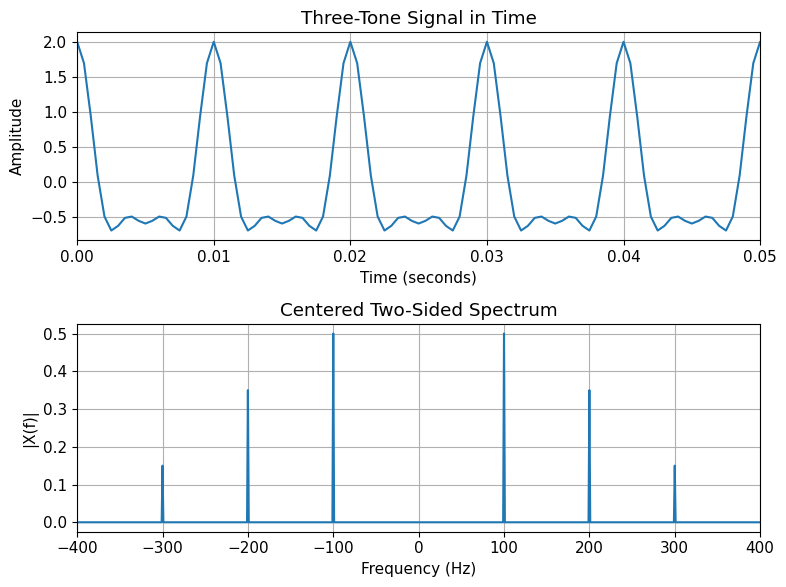

Expected positive-frequency peaks: 100, 200, and 300 Hz


In [2]:
# =========================================================================
# SECTION 1: THREE-TONE SIGNAL
# =========================================================================
# GOAL:
#   Build a finite time-domain signal containing 100, 200, and 300 Hz
#   cosines, compute its centered two-sided FFT, and verify the expected
#   positive- and negative-frequency spectral lines.
#
# KEY VARIABLES:
#   Fs   = sampling rate in samples/second
#   Tobs = observation duration in seconds
#   N    = total number of samples = Fs*Tobs
#   n    = integer sample indices [0,1,...,N-1]
#   t    = physical sample times n/Fs
#
# VECTORIZATION:
#   np.cos(2*np.pi*f1*t) evaluates the cosine at every sample time without an
#   explicit Python loop.
#
# FFT:
#   np.fft.fft(x) returns complex DFT samples.
#   np.fft.fftshift(...) moves zero frequency to the center.
#   division by N normalizes by record length.
#
# FREQUENCY AXIS:
#   FFT-bin spacing is Fs/N = 1/Tobs.
#
# PLOT:
#   ax[0] shows only the first 0.05 s so the time waveform is readable.
#   ax[1] zooms to +/-400 Hz so all six spectral lines are visible.
# =========================================================================

Fs = 2000              # Samples per second
Tobs = 1               # Observation duration in seconds
N = int(Fs * Tobs)     # Number of samples
n = np.arange(N)
t = n / Fs

f1 = 100
f2 = 200
f3 = 300

x = (np.cos(2*np.pi*f1*t)
     + 0.7*np.cos(2*np.pi*f2*t)
     + 0.3*np.cos(2*np.pi*f3*t))

# Centered, two-sided FFT
X = np.fft.fftshift(np.fft.fft(x)) / N
f = (np.arange(-N/2, N/2) * (Fs/N))

fig, ax = plt.subplots(2, 1, figsize=(8, 6))
ax[0].plot(t, x)
ax[0].set_xlim(0, 0.05)
ax[0].set_xlabel("Time (seconds)")
ax[0].set_ylabel("Amplitude")
ax[0].set_title("Three-Tone Signal in Time")

ax[1].plot(f, np.abs(X))
ax[1].set_xlim(-400, 400)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("|X(f)|")
ax[1].set_title("Centered Two-Sided Spectrum")
plt.tight_layout()
plt.show()

print(f"Expected positive-frequency peaks: {f1}, {f2}, and {f3} Hz")

## 2. FFT resolution and record duration

### Prediction

What happens to \(\Delta f\) when the observation time doubles while the sampling rate stays fixed?

\[
\Delta f = \frac{F_s}{N}.
\]

Since \(N=F_sT_{\mathrm{obs}}\),

\[
\Delta f=\frac{1}{T_{\mathrm{obs}}}.
\]

Therefore:

- 1 second → 1 Hz bin spacing
- 2 seconds → 0.5 Hz bin spacing

The tones are 100 and 100.5 Hz, so the longer observation provides the finer frequency grid needed to distinguish them much more clearly.

**Key message:** frequency resolution improves because we observed longer, not because we sampled faster.


One-second record: Delta f = 1.00 Hz
Two-second record: Delta f = 0.50 Hz



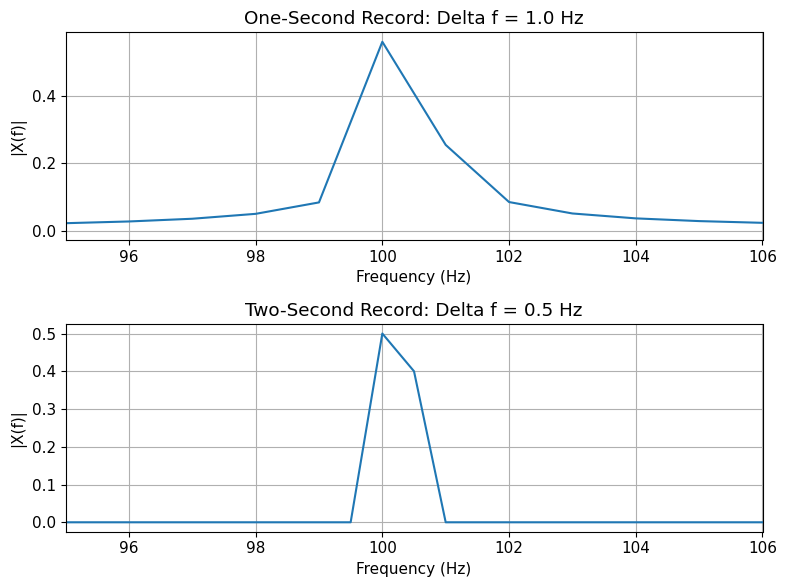

In [3]:
# =========================================================================
# SECTION 2: FFT RESOLUTION VERSUS OBSERVATION TIME
# =========================================================================
# GOAL:
#   Keep Fs fixed while doubling record duration.
#
# One-second record:
#   Fs = 1000 samples/s
#   N  = 1000
#   Delta f = Fs/N = 1 Hz
#
# Two-second record:
#   Fs = 1000 samples/s
#   N  = 2000
#   Delta f = Fs/N = 0.5 Hz
#
# Both records contain tones at 100 and 100.5 Hz.
#
# TEACHING POINT:
#   The longer record has more FFT samples and therefore a finer frequency
#   grid. This is the concrete demonstration of
#
#       Delta f = Fs/N = 1/Tobs.
#
# Nothing about the analog tones or sampling frequency changes.
# =========================================================================

FsR = 1000

# One-second record
# Less accurate because it's a larger bin.
Nshort = 1000
t_short = np.arange(Nshort) / FsR
x_short = np.cos(2*np.pi*100*t_short) + 0.8*np.cos(2*np.pi*100.5*t_short)
X_short = np.fft.fftshift(np.fft.fft(x_short)) / Nshort
f_short = (np.arange(-Nshort/2, Nshort/2) * (FsR/Nshort))

# Two-second record
# Shows up as 0.4 and 0.5 on the graph because cos splits as 1/2e+ + 1/2e- with trig identities.
Nlong = 2000
t_long = np.arange(Nlong) / FsR
x_long = np.cos(2*np.pi*100*t_long) + 0.8*np.cos(2*np.pi*100.5*t_long)
X_long = np.fft.fftshift(np.fft.fft(x_long)) / Nlong
f_long = (np.arange(-Nlong/2, Nlong/2) * (FsR/Nlong))

delta_f_short = FsR / Nshort
delta_f_long = FsR / Nlong

print(f"One-second record: Delta f = {delta_f_short:.2f} Hz")
print(f"Two-second record: Delta f = {delta_f_long:.2f} Hz")
print()

fig, ax = plt.subplots(2, 1, figsize=(8, 6))
ax[0].plot(f_short, np.abs(X_short))
ax[0].set_xlim(95, 106)
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("|X(f)|")
ax[0].set_title(f"One-Second Record: Delta f = {delta_f_short:.1f} Hz")

ax[1].plot(f_long, np.abs(X_long))
ax[1].set_xlim(95, 106)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("|X(f)|")
ax[1].set_title(f"Two-Second Record: Delta f = {delta_f_long:.1f} Hz")
plt.tight_layout()
plt.show() 

## 3. Rectangular pulse and sinc spectrum

### Prediction

For \(T_p=0.25\) s, where should the first sinc zero pair appear?

A rectangular pulse in time has a sinc-shaped Fourier transform. Its first zeros occur at

\[
f=\pm\frac{1}{T_p}.
\]

Thus, for \(T_p=0.25\) s,

\[
f=\pm4\text{ Hz}.
\]

### Teaching focus

This is the classic time-frequency tradeoff:

> A narrower event in time spreads more broadly in frequency.

The use of `ifftshift` before the FFT is bookkeeping: the time vector is centered around zero, while the FFT routine expects its first array element to represent the start of its periodic record.


Pulse duration: 0.250 seconds
Expected first zero pair: +/- 4.00 Hz



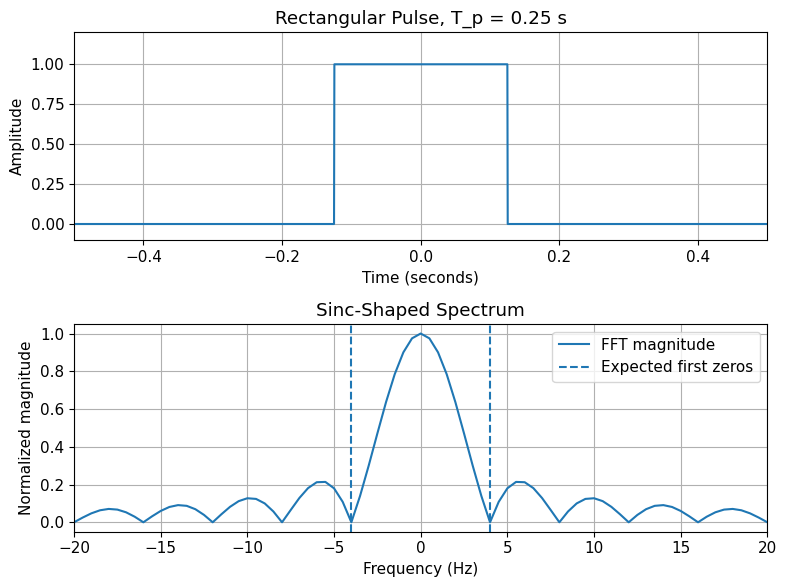

In [4]:
# =========================================================================
# SECTION 3: RECTANGULAR PULSE -> SINC SPECTRUM
# =========================================================================
# GOAL:
#   Numerically demonstrate the Fourier-transform pair between a rectangular
#   pulse in time and a sinc-shaped spectrum.
#
# t_rect:
#   np.arange(-Tspan/2, Tspan/2, 1/Fs_rect) creates a time vector centered
#   around zero.
#
# x_rect:
#   (np.abs(t_rect) <= Tp/2) produces Boolean True/False values.
#   .astype(float) converts them to 1.0/0.0, creating the rectangle.
#
# SHIFTING:
#   Because the pulse is visually centered at t=0 in the middle of the array,
#   ifftshift rearranges the samples before fft.
#   fftshift then recenters the resulting spectrum for plotting.
#
# NORMALIZATION:
#   X_rect / max(X_rect) makes the peak magnitude equal to 1 so the shape and
#   zero locations are the focus.
#
# THEORY:
#   First sinc zeros occur at +/-1/Tp = +/-4 Hz.
# =========================================================================

Fs_rect = 2000
Tspan = 2
t_rect = np.arange(-Tspan/2, Tspan/2, 1/Fs_rect)

Tp = 0.25
x_rect = (np.abs(t_rect) <= Tp/2).astype(float)
Nrect = len(x_rect)

# The time record is centered around zero, so use ifftshift before fft.
X_rect = np.fft.fftshift(np.fft.fft(np.fft.ifftshift(x_rect)))
X_rect = np.abs(X_rect)
X_rect = X_rect / np.max(X_rect)
f_rect = np.arange(-Nrect/2, Nrect/2) * (Fs_rect/Nrect)

first_zero = 1 / Tp

print(f"Pulse duration: {Tp:.3f} seconds")
print(f"Expected first zero pair: +/- {first_zero:.2f} Hz")
print()

fig, ax = plt.subplots(2, 1, figsize=(8, 6))
ax[0].plot(t_rect, x_rect)
ax[0].set_xlim(-0.5, 0.5)
ax[0].set_ylim(-0.1, 1.2)
ax[0].set_xlabel("Time (seconds)")
ax[0].set_ylabel("Amplitude")
ax[0].set_title(f"Rectangular Pulse, T_p = {Tp:.2f} s")

ax[1].plot(f_rect, X_rect, label="FFT magnitude")
ax[1].axvline(first_zero, linestyle="--", label="Expected first zeros")
ax[1].axvline(-first_zero, linestyle="--")
ax[1].set_xlim(-20, 20)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Normalized magnitude")
ax[1].set_title("Sinc-Shaped Spectrum")
ax[1].legend()
plt.tight_layout()
plt.show()

## 4. Autocorrelation: sinusoid versus noise

Autocorrelation compares a sequence with shifted copies of itself.

Conceptually,


$R_{xx}[k]\propto \sum_n x[n]x[n+k]$.

The integer \(k\) is called the **lag**.

### Prediction

A sinusoid should correlate strongly again whenever the lag corresponds to another cycle alignment. Therefore its autocorrelation remains periodic.

White noise should have a dominant zero-lag correlation and much smaller values away from zero because distinct ideal white-noise samples are uncorrelated.

### Teaching distinction

The FFT asks:

> What frequency content is present?

Autocorrelation asks:

> How similar is this record to a shifted copy of itself?


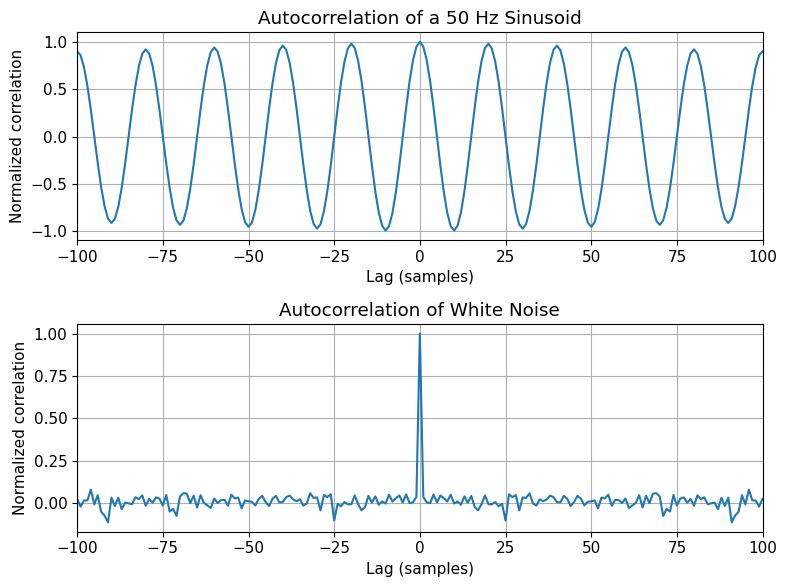

In [5]:
# =========================================================================
# SECTION 4: AUTOCORRELATION
# =========================================================================
# GOAL:
#   Compare the lag structure of a periodic deterministic sinusoid with that
#   of a white-noise realization.
#
# PYTHON FUNCTION:
#   def biased_autocorrelation(x):
#       ...
#   defines a reusable function. Indentation, not braces, defines its body.
#
# np.correlate(x,x,mode="full"):
#   computes all relative shifts between two copies of x, producing 2N-1
#   correlation samples.
#
# WHY "BIASED":
#   The result is divided by N at every lag. Near large positive/negative lags
#   fewer sample pairs overlap, but the denominator stays N.
#
# RETURN VALUES:
#   Python can return multiple values. "R_sin, lags = ..." unpacks them.
#   "_" conventionally means "I am intentionally ignoring this returned item."
#
# NORMALIZATION:
#   Each autocorrelation is divided by its own largest magnitude only to make
#   the shapes visually comparable.
# =========================================================================

def biased_autocorrelation(x):
    """Return biased full autocorrelation and integer lags."""
    x = np.asarray(x)
    N = len(x)
    r = np.correlate(x, x, mode="full") / N
    lags = np.arange(-(N-1), N)
    return r, lags

Fs_corr = 1000
Ncorr = 1000
t_corr = np.arange(Ncorr) / Fs_corr

x_sin = np.cos(2*np.pi*50*t_corr)
x_noise = rng.standard_normal(Ncorr)

R_sin, lags = biased_autocorrelation(x_sin)
R_noise, _ = biased_autocorrelation(x_noise)

# Normalize so the shapes are easy to compare.
R_sin = R_sin / np.max(np.abs(R_sin))
R_noise = R_noise / np.max(np.abs(R_noise))

fig, ax = plt.subplots(2, 1, figsize=(8, 6))
ax[0].plot(lags, R_sin)
ax[0].set_xlim(-100, 100)
ax[0].set_xlabel("Lag (samples)")
ax[0].set_ylabel("Normalized correlation")
ax[0].set_title("Autocorrelation of a 50 Hz Sinusoid")

ax[1].plot(lags, R_noise)
ax[1].set_xlim(-100, 100)
ax[1].set_xlabel("Lag (samples)")
ax[1].set_ylabel("Normalized correlation")
ax[1].set_title("Autocorrelation of White Noise")
plt.tight_layout()
plt.show()

## 5. FFT and PSD: clean versus noisy signal

The PSD estimate is computed with a simple Welch-style average so the notebook does not require SciPy.

### FFT versus PSD

The FFT is the complex spectrum of one finite record.

The **power spectral density (PSD)** describes how average power is distributed over frequency, normally expressed as power per hertz.

A Welch estimate reduces the random variability of a raw periodogram by:

1. breaking the record into overlapping segments,
2. windowing each segment,
3. computing a spectrum for each,
4. converting magnitude to power,
5. averaging those power spectra.

### Why target 0 dB SNR?

$
\mathrm{SNR}_{dB}=10\log_{10}\left(\frac{P_s}{P_n}\right).
$

At 0 dB,

$
\frac{P_s}{P_n}=1,
$

so the target signal power and target noise power are equal.


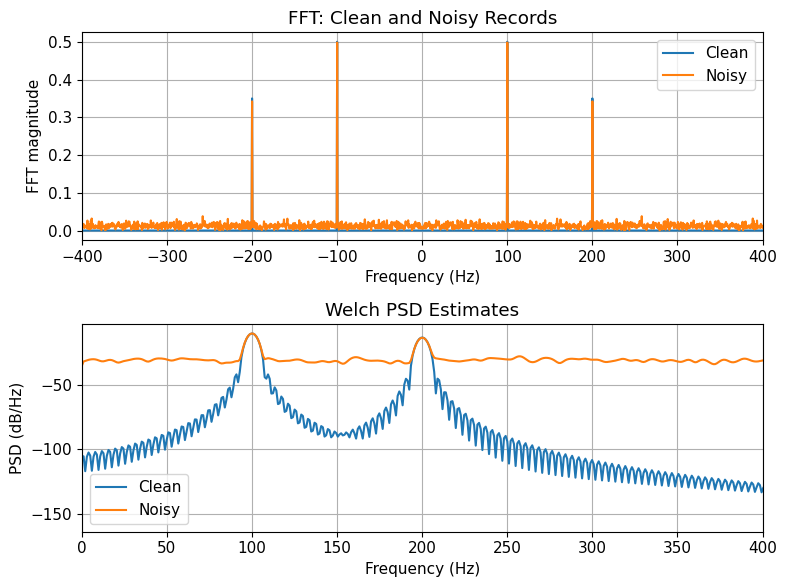

Clean signal power: 0.7450
Target noise power: 0.7450
Measured noise power: 0.7540



In [6]:
# =========================================================================
# SECTION 5: FFT AND WELCH-STYLE PSD
# =========================================================================
# GOAL:
#   Compare a conventional FFT with an averaged estimate of power spectral
#   density for clean and noisy records.
#
# helper function simple_welch_psd(...)
# -------------------------------------
# nperseg:
#   number of samples in each short analysis segment.
#
# noverlap:
#   number of samples shared by neighboring segments.
#
# step = nperseg - noverlap:
#   number of samples by which we advance for each new segment.
#
# np.hanning(nperseg):
#   creates a Hann window. Windowing reduces leakage caused by abrupt segment
#   boundaries.
#
# np.fft.rfft(...):
#   FFT optimized for real input. It returns only nonnegative frequencies.
#
# POWER:
#   abs(spectrum)**2 converts FFT magnitude to squared magnitude.
#
# ONE-SIDED PSD:
#   For a real signal, negative-frequency power mirrors positive-frequency
#   power. After discarding the negative side, interior positive-frequency
#   bins are doubled to preserve total power.
#
# psd_segments:
#   ordinary Python list containing one PSD array per Welch segment.
#
# np.mean(psd_segments, axis=0):
#   averages corresponding frequency bins across segments.
#
# 0 dB SNR construction
# ---------------------
# SNRdB = 0 -> SNR_linear = 1.
# Therefore target noise power equals measured clean signal power.
#
# The measured random-noise power will be close to, but not exactly equal to,
# the target because the record is finite.
#
# np.finfo(float).eps:
#   tiny positive floating-point value added before log10 so an exact zero PSD
#   bin cannot produce log10(0) = -infinity.
# =========================================================================

def simple_welch_psd(x, fs, nperseg=512, noverlap=256, nfft=2048):
    """One-sided Welch PSD estimate using a Hann window and 50% overlap."""
    x = np.asarray(x)
    step = nperseg - noverlap
    if step <= 0:
        raise ValueError("nperseg must be greater than noverlap")
    window = np.hanning(nperseg)
    scale = fs * np.sum(window**2)
    starts = np.arange(0, len(x) - nperseg + 1, step)
    psd_segments = []
    for start in starts:
        segment = x[start:start+nperseg]
        spectrum = np.fft.rfft(segment * window, n=nfft)
        psd = (np.abs(spectrum)**2) / scale
        if nfft % 2 == 0:
            psd[1:-1] *= 2
        else:
            psd[1:] *= 2
        psd_segments.append(psd)
    Pxx = np.mean(psd_segments, axis=0)
    f_welch = np.fft.rfftfreq(nfft, d=1/fs)
    return f_welch, Pxx

FsP = 2000
TobsP = 2
NP = int(FsP * TobsP)
tP = np.arange(NP) / FsP

x_clean = np.cos(2*np.pi*100*tP) + 0.7*np.cos(2*np.pi*200*tP)
signal_power = np.mean(np.abs(x_clean)**2)

SNRdB = 0
noise_power = signal_power / 10**(SNRdB/10)
noise = np.sqrt(noise_power) * rng.standard_normal(x_clean.shape)
x_noisy = x_clean + noise

X_clean = np.fft.fftshift(np.fft.fft(x_clean)) / NP
X_noisy = np.fft.fftshift(np.fft.fft(x_noisy)) / NP
fP = np.arange(-NP/2, NP/2) * (FsP/NP)

f_welch, P_clean = simple_welch_psd(x_clean, FsP, nperseg=512, noverlap=256, nfft=2048)
_, P_noisy = simple_welch_psd(x_noisy, FsP, nperseg=512, noverlap=256, nfft=2048)

fig, ax = plt.subplots(2, 1, figsize=(8, 6))
ax[0].plot(fP, np.abs(X_clean), label="Clean")
ax[0].plot(fP, np.abs(X_noisy), label="Noisy")
ax[0].set_xlim(-400, 400)
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("FFT magnitude")
ax[0].set_title("FFT: Clean and Noisy Records")
ax[0].legend()

ax[1].plot(f_welch, 10*np.log10(P_clean + np.finfo(float).eps), label="Clean")
ax[1].plot(f_welch, 10*np.log10(P_noisy + np.finfo(float).eps), label="Noisy")
ax[1].set_xlim(0, 400)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("PSD (dB/Hz)")
ax[1].set_title("Welch PSD Estimates")
ax[1].legend()
plt.tight_layout()
plt.show()

print(f"Clean signal power: {signal_power:.4f}")
print(f"Target noise power: {noise_power:.4f}")
print(f"Measured noise power: {np.mean(np.abs(noise)**2):.4f}")
print()

## 6. Samples per period and cycles in the record

This mirrors Board 4.

Three simple relationships connect the sample rate, tone frequency, and finite record:

$
\text{samples per period}=\frac{F_s}{f_0},
$

$
T_{\mathrm{obs}}=\frac{N}{F_s},
$

and

$
\text{cycles in record}=f_0T_{\mathrm{obs}}.
$

This is useful because students often know \(F_s\), \(f_0\), and \(N\) but do not immediately translate them into what the discrete waveform should look like.


In [7]:
# =========================================================================
# SECTION 6: SAMPLE-RATE GEOMETRY
# =========================================================================
# GOAL:
#   Translate Fs, f0, and N into intuitive properties of a finite sampled
#   sinusoid.
#
# samples_per_period = Fs/f0
#   How many discrete samples occur during one analog sinusoid period?
#
# Tobs = N/Fs
#   How many seconds does the finite N-sample record represent?
#
# cycles_in_record = f0*Tobs
#   How many sinusoid cycles fit inside the finite observation?
#
# With Fs=1000 Hz, f0=80 Hz, and N=500:
#   samples/period = 12.5
#   duration       = 0.5 s
#   cycles         = 40
# =========================================================================

Fs_sample = 1000
f0_sample = 80
N_sample = 500

samples_per_period = Fs_sample / f0_sample
Tobs_sample = N_sample / Fs_sample
cycles_in_record = f0_sample * Tobs_sample

print(f"Sampling rate: {Fs_sample:.0f} samples/s")
print(f"Tone frequency: {f0_sample:.0f} Hz")
print(f"Samples per period: {samples_per_period:.2f}")
print(f"Observation duration: {Tobs_sample:.2f} seconds")
print(f"Cycles in record: {cycles_in_record:.0f}")
print()

Sampling rate: 1000 samples/s
Tone frequency: 80 Hz
Samples per period: 12.50
Observation duration: 0.50 seconds
Cycles in record: 40



## 7. Aliasing demonstration

### Prediction

What apparent frequency should a 760 Hz tone have when sampled at 1000 samples/s?

The Nyquist frequency is

$
F_s/2=500\text{ Hz}.
$

The 760 Hz tone exceeds Nyquist. Frequencies separated by integer multiples of \(F_s\) produce the same discrete-time samples.

Here,

$
|760-1000|=240\text{ Hz}.
$

So the samples are indistinguishable from those of a 240 Hz cosine.

### Teaching point

Aliasing happens **at sampling**. The FFT merely reveals the aliased discrete-time signal that now exists.


Original analog frequency: 760 Hz
Sampling frequency: 1000 Hz
Theoretical alias: 240 Hz
Measured FFT peak: 240 Hz



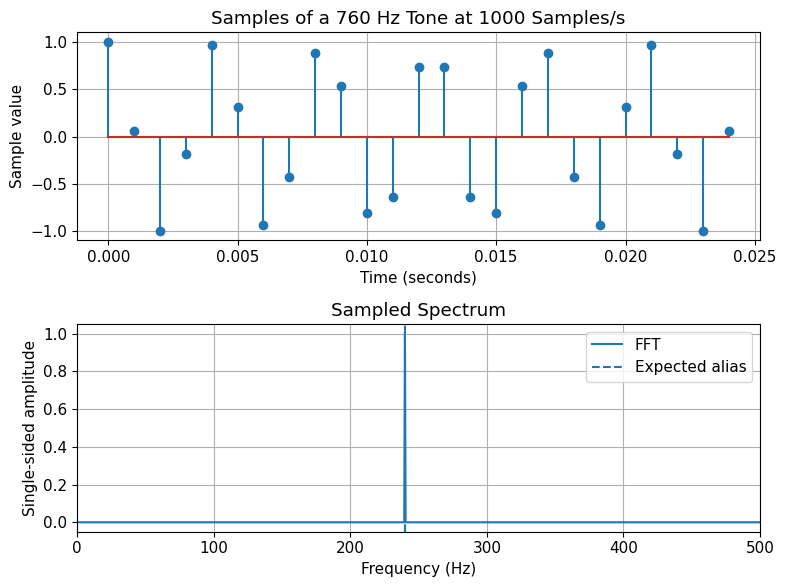

In [8]:
# =========================================================================
# SECTION 7: ALIASING
# =========================================================================
# GOAL:
#   Show that a 760 Hz analog cosine sampled at 1000 samples/s appears at
#   240 Hz in discrete time.
#
# NYQUIST:
#   Fs/2 = 500 Hz, so 760 Hz is above Nyquist.
#
# SAMPLE GENERATION:
#   x_alias still uses 760 Hz in the formula. The important result is that
#   these sample VALUES are identical to samples from an aliased frequency.
#
# SINGLE-SIDED AMPLITUDE SPECTRUM:
#   P2 is the normalized two-sided magnitude.
#   P1 keeps only DC through Nyquist.
#   P1[1:-1] *= 2 restores the amplitude contribution that had an equal mirror
#   on the discarded negative-frequency side.
#
# // in Python:
#   integer/floor division. N_alias//2 gives 1000.
#
# .copy():
#   creates an independent array before P1 is modified.
#
# np.argmax(P1):
#   returns the INDEX of the largest spectrum value, not the value itself.
#
# THEORY:
#   abs(760 - round(760/1000)*1000) = 240 Hz.
#
# IMPORTANT:
#   The FFT does not create the alias. Sampling created it.
# =========================================================================

Fs_alias = 1000
f_original = 760
N_alias = 2000

n_alias = np.arange(N_alias)
t_alias = n_alias / Fs_alias
x_alias = np.cos(2*np.pi*f_original*t_alias)

# Compute the apparent positive-frequency peak.
X_alias = np.fft.fft(x_alias)
P2 = np.abs(X_alias / N_alias)
P1 = P2[:N_alias//2 + 1].copy()
P1[1:-1] *= 2
f_axis_alias = Fs_alias * np.arange(N_alias//2 + 1) / N_alias

peak_index = np.argmax(P1)
measured_alias = f_axis_alias[peak_index]
theoretical_alias = abs(f_original - round(f_original/Fs_alias)*Fs_alias)

print(f"Original analog frequency: {f_original:.0f} Hz")
print(f"Sampling frequency: {Fs_alias:.0f} Hz")
print(f"Theoretical alias: {theoretical_alias:.0f} Hz")
print(f"Measured FFT peak: {measured_alias:.0f} Hz")
print()

fig, ax = plt.subplots(2, 1, figsize=(8, 6))
markerline, stemlines, baseline = ax[0].stem(t_alias[:25], x_alias[:25])
ax[0].set_xlabel("Time (seconds)")
ax[0].set_ylabel("Sample value")
ax[0].set_title("Samples of a 760 Hz Tone at 1000 Samples/s")

ax[1].plot(f_axis_alias, P1, label="FFT")
ax[1].axvline(theoretical_alias, linestyle="--", label="Expected alias")
ax[1].set_xlim(0, Fs_alias/2)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("Single-sided amplitude")
ax[1].set_title("Sampled Spectrum")
ax[1].legend()
plt.tight_layout()
plt.show()

## 8. Ideal low-pass filtering

### Prediction

Which tones survive a 250 Hz low-pass filter?

Input tones:

- 100 Hz
- 200 Hz
- 300 Hz

For an ideal cutoff at 250 Hz:

- 100 Hz passes,
- 200 Hz passes,
- 300 Hz is removed.

The central filtering relationship is

$
Y(f)=X(f)H(f).
$

The code creates an ideal rectangular \(H(f)\), multiplies the input FFT by it, and then uses an inverse FFT to return to the time domain.

This ideal brick-wall response is pedagogical. A finite real filter requires a transition band.


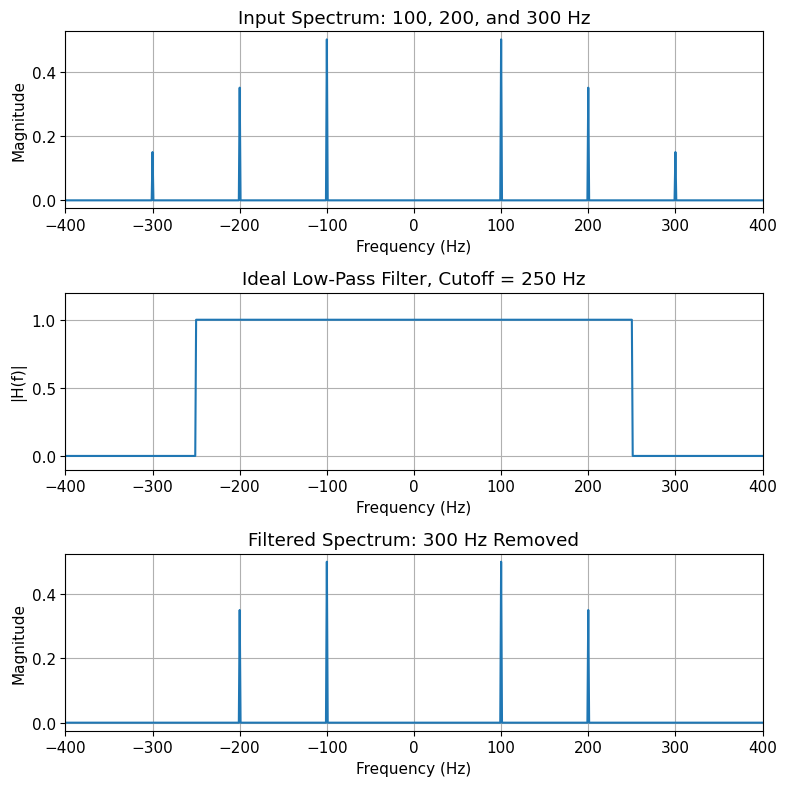

In [9]:
# =========================================================================
# SECTION 8: IDEAL LOW-PASS FILTERING
# =========================================================================
# GOAL:
#   Filter a 100/200/300 Hz three-tone signal with an ideal 250 Hz low-pass.
#
# X_filter:
#   centered FFT of the input.
#
# H:
#   Boolean frequency mask converted to floating point.
#   |f| <= 250 -> 1.0
#   |f| >  250 -> 0.0
#
# Y_filter = X_filter * H:
#   element-by-element multiplication implementing
#       Y(f) = X(f)H(f).
#
# RESULT:
#   +/-100 and +/-200 Hz spectral lines remain.
#   +/-300 Hz lines are multiplied by zero.
#
# INVERSE FFT:
#   ifftshift undoes the plotting-oriented centering.
#   ifft returns the time-domain signal.
#
# np.real(...):
#   mathematically the output is real, but tiny imaginary values can appear
#   from floating-point FFT roundoff. np.real discards those numerical crumbs.
#
# This is an IDEAL brick-wall filter used for concept demonstration, not a
# finite physically realizable implementation.
# =========================================================================

Fs_filter = 2000
T_filter = 1
N_filter = int(Fs_filter * T_filter)
t_filter = np.arange(N_filter) / Fs_filter

x_filter = (np.cos(2*np.pi*100*t_filter)
            + 0.7*np.cos(2*np.pi*200*t_filter)
            + 0.3*np.cos(2*np.pi*300*t_filter))

X_filter = np.fft.fftshift(np.fft.fft(x_filter))
f_filter = np.arange(-N_filter/2, N_filter/2) * (Fs_filter/N_filter)

cutoff = 250

# Ideal low-pass magnitude response
H = (np.abs(f_filter) <= cutoff).astype(float)

# Apply the filter in the frequency domain
Y_filter = X_filter * H

# Return to time domain
_y_filter = np.fft.ifft(np.fft.ifftshift(Y_filter))
y_filter = np.real(_y_filter)

fig, ax = plt.subplots(3, 1, figsize=(8, 8))
ax[0].plot(f_filter, np.abs(X_filter)/N_filter)
ax[0].set_xlim(-400, 400)
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Magnitude")
ax[0].set_title("Input Spectrum: 100, 200, and 300 Hz")

ax[1].plot(f_filter, H)
ax[1].set_xlim(-400, 400)
ax[1].set_ylim(-0.1, 1.2)
ax[1].set_xlabel("Frequency (Hz)")
ax[1].set_ylabel("|H(f)|")
ax[1].set_title("Ideal Low-Pass Filter, Cutoff = 250 Hz")

ax[2].plot(f_filter, np.abs(Y_filter)/N_filter)
ax[2].set_xlim(-400, 400)
ax[2].set_xlabel("Frequency (Hz)")
ax[2].set_ylabel("Magnitude")
ax[2].set_title("Filtered Spectrum: 300 Hz Removed")
plt.tight_layout()
plt.show()

## 9. Demonstration summary

The final cell prints the Week 2 takeaways.

A useful verbal recap is:

> We started with finite sampled records, learned how the FFT maps them into frequency, saw that longer records sharpen the frequency grid, connected time localization to spectral spreading, introduced correlation and PSD, then closed the loop with sampling, aliasing, and filtering.


In [10]:
# =========================================================================
# SECTION 9: WEEK 2 SUMMARY
# =========================================================================
# These are intentionally plain print statements. The purpose is to leave a
# concise verbal checklist visible at the end of the notebook.
# =========================================================================

print()
print("WEEK 2 SUMMARY")
print("1. The FFT identifies frequency components.")
print("2. Delta f = Fs/N = 1/Tobs.")
print("3. Rectangle in time gives sinc in frequency.")
print("4. Autocorrelation reveals repetition versus lag.")
print("5. PSD shows power distributed over frequency.")
print("6. Sampling below Nyquist produces aliasing.")
print("7. A low-pass filter passes low frequencies and rejects high ones.")


WEEK 2 SUMMARY
1. The FFT identifies frequency components.
2. Delta f = Fs/N = 1/Tobs.
3. Rectangle in time gives sinc in frequency.
4. Autocorrelation reveals repetition versus lag.
5. PSD shows power distributed over frequency.
6. Sampling below Nyquist produces aliasing.
7. A low-pass filter passes low frequencies and rejects high ones.
